## MCMC Corner plot

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams["text.usetex"] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Palatino'
#plt.rcParams['font.weight'] = '700'
#plt.rcParams['axes.labelweight'] = '700'

plt.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 14,
    "figure.dpi": 300,
    "axes.linewidth": 1.4,
})

In [3]:
data = pd.read_csv("/Users/sahananarasimha/protomodels/results_sahana/mcmc_run/mcmc.csv")

In [4]:
cols = ['X1Z mass', 'X2Z mass',  'X1W mass', 'X3Z mass']
data = data[cols]
data


,X1Z mass,X2Z mass,X1W mass,X3Z mass
0,89.88887,126.046269,155.494055,421.065510
1,89.88887,126.046269,155.494055,421.065510
2,89.88887,169.729497,155.494055,421.065510
3,89.88887,108.765541,155.494055,421.065510
4,89.88887,126.046269,155.494055,557.477936
...,...,...,...,...
452798,390.01377,450.446366,439.631767,699.144192
452799,390.01377,450.446366,439.631767,741.867773
452800,390.01377,450.446366,439.631767,741.867773
452801,390.01377,450.446366,463.942438,741.867773


In [6]:
best_point = {1000022: 89.88887,
            1000023: 126.046269,
            1000024: 155.494055,
            1000025: 451.88620440330646}

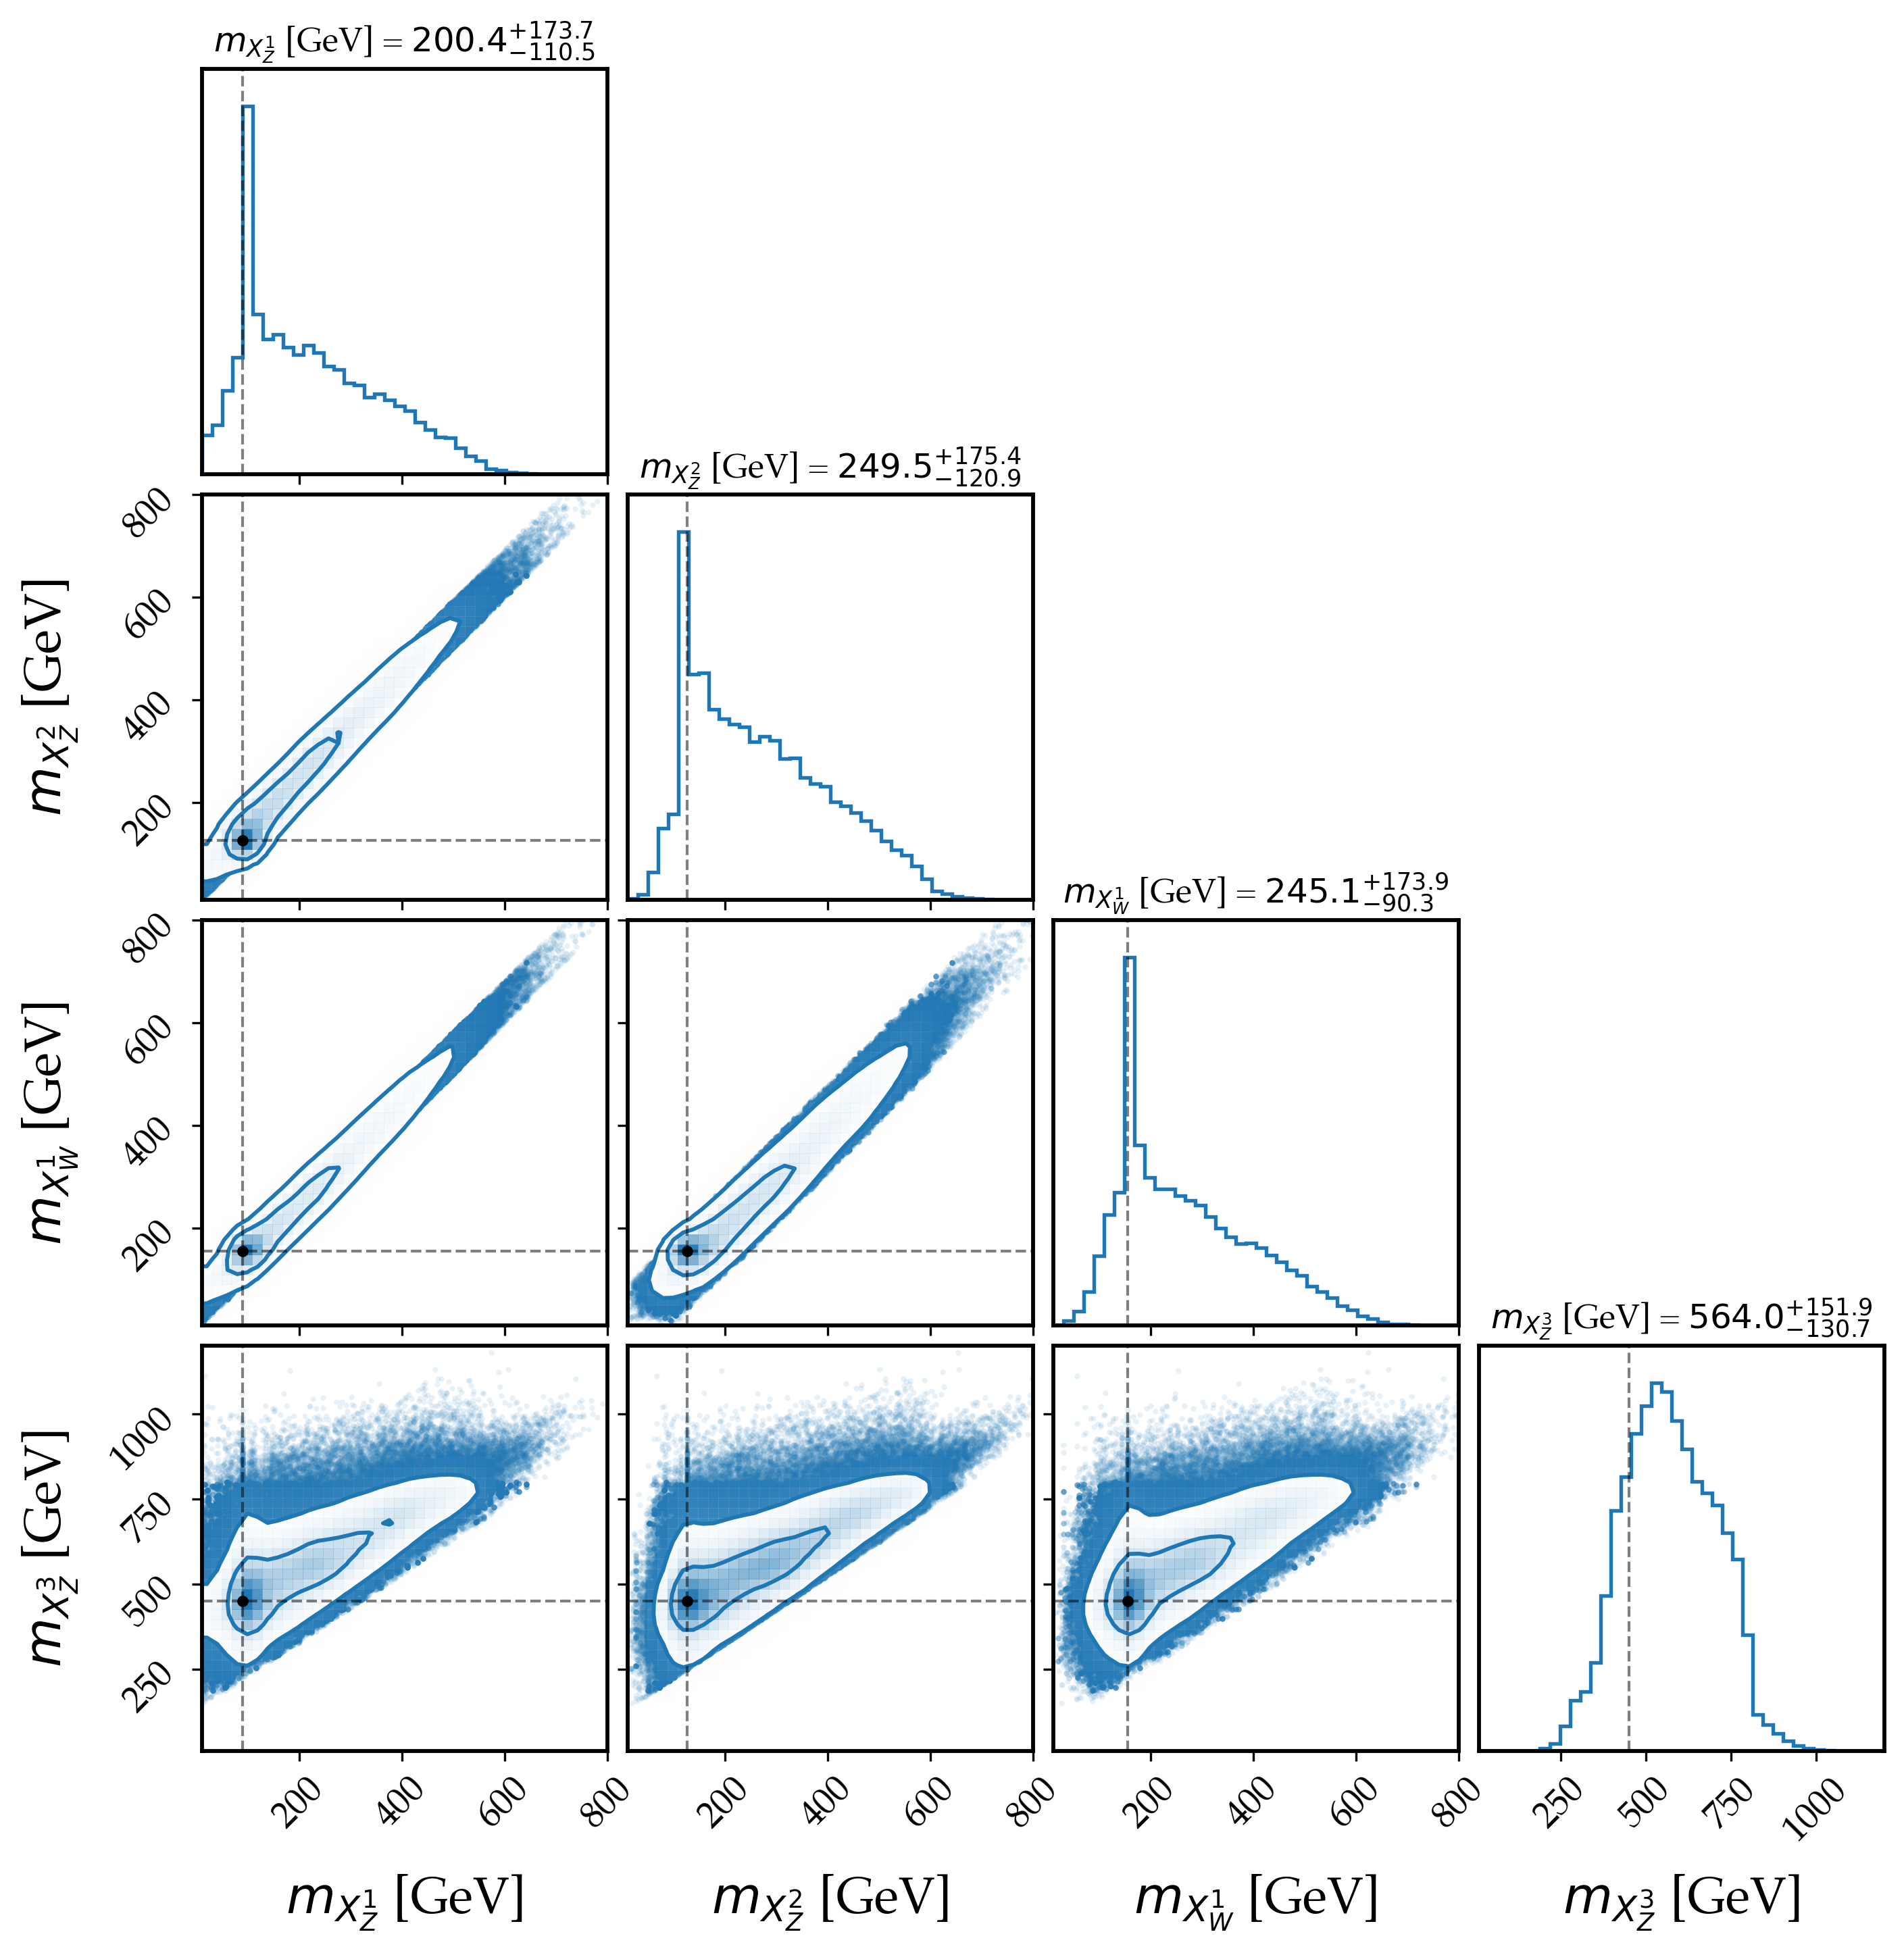

'\nfigure = corner.corner(samples, labels=data.columns, quantiles=[0.16, 0.5, 0.84], \n                        range=[(10,1000), (10,1500), (10,2500), (10,2500)], # (1e-04, 50), (1e-04, 1e01), (1e-04,50), (1e-07,10),(1e-04,50)], \n                        axes_scale = ["linear"]*4,   show_titles=True) #+["log"]*5,\n'

In [7]:
# Create corner plots
import corner

# Convert DataFrame to NumPy array
samples = data.to_numpy() 

best_fit_dict = {'X1Z mass': 89.88887,'X2Z mass': 126.046269,'X1W mass': 155.494055,'X3Z mass': 451.88620440330646}
param_order = ['X1Z mass', 'X2Z mass',  'X1W mass', 'X3Z mass']
best_fit = np.array([best_fit_dict[p] for p in param_order])


labels = [
    r"$m_{X_Z^1}$" + " [GeV]",
    r"$m_{X_Z^2}$" + " [GeV]",
    r"$m_{X_W^1}$" + " [GeV]",
    r"$m_{X_Z^3}$" + " [GeV]", 
]
title_fmt = ".1f"
title_kwargs = {"fontsize": 12}

main_color = "#1f77b4"        
fill_color = "#aec7e8"       

figure = corner.corner(samples,labels=labels,range=[(10,800), (10,800), (10,800), (10,1200)],#quantiles=[0.16,0.5,0.84],
    show_titles=True,title_fmt=title_fmt,title_kwargs=title_kwargs,
    bins=40,smooth=1.0,plot_contours=True,fill_contours=False,levels=(0.393, 0.864),#levels=(0.68, 0.95),
    color=main_color,hist_kwargs={"linewidth": 1.3, "color":main_color},contour_kwargs={"linewidths": 1.4},#contourf_kwargs={"colors": [fill_color]},
    plot_datapoints=True,datapoints_kwargs={"alpha": 0.1, "color":main_color,"markersize": 1},
)

corner.overplot_lines(figure,best_fit,color="black",linestyle='--',linewidth=1, alpha=0.5)

corner.overplot_points(figure,best_fit[None, :],color="black",marker="o",markersize=3)

for ax in figure.get_axes():
    ax.tick_params(axis="both", which="major", labelsize=13)

plt.show()


'''
#if you want to plot ssm, use axes_scale=log
figure = corner.corner(samples, labels=data.columns, quantiles=[0.16, 0.5, 0.84], 
                        range=[(10,1000), (10,1500), (10,2500), (10,2500)], # (1e-04, 50), (1e-04, 1e01), (1e-04,50), (1e-07,10),(1e-04,50)], 
                        axes_scale = ["linear"]*4,   show_titles=True) #+["log"]*5,
'''